<a href="https://colab.research.google.com/github/aswinimishra82-hue/Aswini-Kumar-Mishra-/blob/main/aswini282.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Decoherence time data set for  AIQMR.xlsx to Decoherence time data set for  AIQMR.xlsx


In [ ]:
import pandas as pd

df = pd.read_excel('Decoherence time data set for  AIQMR.xlsx')
df.head()

,Ec_meV,E0_V_per_m,tau_ns,Temp_mK,Noise_meV,T2_us
0,2.84,25196,22.8,110,0.018,4.76
1,4.10,40798,9.3,40,0.011,7.19
2,4.07,69839,12.8,40,0.040,7.19
3,2.13,69968,20.8,25,0.035,7.94
4,3.86,62710,20.2,37,0.042,7.12


In [ ]:
print(df.shape)
print(df.columns)
print(df.describe())

(250, 6)
Index(['Ec_meV', 'E0_V_per_m', 'tau_ns', 'Temp_mK', 'Noise_meV', 'T2_us'], dtype='object')
           Ec_meV    E0_V_per_m      tau_ns     Temp_mK   Noise_meV  \
count  250.000000    250.000000  250.000000  250.000000  250.000000   
mean     3.209480  45468.268000   16.084000   67.876000    0.043916   
std      0.741628  14396.711572    4.935893   29.840483    0.020297   
min      2.000000  20316.000000    8.000000   20.000000    0.010000   
25%      2.562500  34184.250000   11.925000   41.000000    0.026250   
50%      3.170000  46191.500000   16.100000   68.000000    0.044500   
75%      3.852500  56895.750000   20.275000   95.000000    0.061000   
max      4.500000  69968.000000   24.900000  120.000000    0.080000   

            T2_us  
count  250.000000  
mean     5.873760  
std      1.018466  
min      3.550000  
25%      5.132500  
50%      5.850000  
75%      6.655000  
max      7.940000  


In [ ]:
X = df[['Ec_meV', 'E0_V_per_m', 'tau_ns', 'Temp_mK', 'Noise_meV']]
y = df['T2_us']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1))

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [ ]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))

model.add(Dense(1))  # output layer

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    verbose=0)

print(f"Final training MAE: {history.history['mae'][-1]:.4f}")
print(f"Final validation MAE: {history.history['val_mae'][-1]:.4f}")

Final training MAE: 0.0025
Final validation MAE: 0.0476


In [ ]:
y_pred = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [ ]:
# Inverse transform the scaled predictions and actual values
y_pred_original = scaler_y.inverse_transform(y_pred)
y_test_original = scaler_y.inverse_transform(y_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test_original, y_pred_original)
mse = mean_squared_error(y_test_original, y_pred_original)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred_original)

print(f"Mean Absolute Error (MAE) on original scale: {mae:.4f}")
print(f"Mean Squared Error (MSE) on original scale: {mse:.4f}")
print(f"Root Mean Squared Error (RMSE) on original scale: {rmse:.4f}")
print(f"R-squared (R2) on original scale: {r2:.4f}")

Mean Absolute Error (MAE) on original scale: 0.0483
Mean Squared Error (MSE) on original scale: 0.0046
Root Mean Squared Error (RMSE) on original scale: 0.0681
R-squared (R2) on original scale: 0.9951


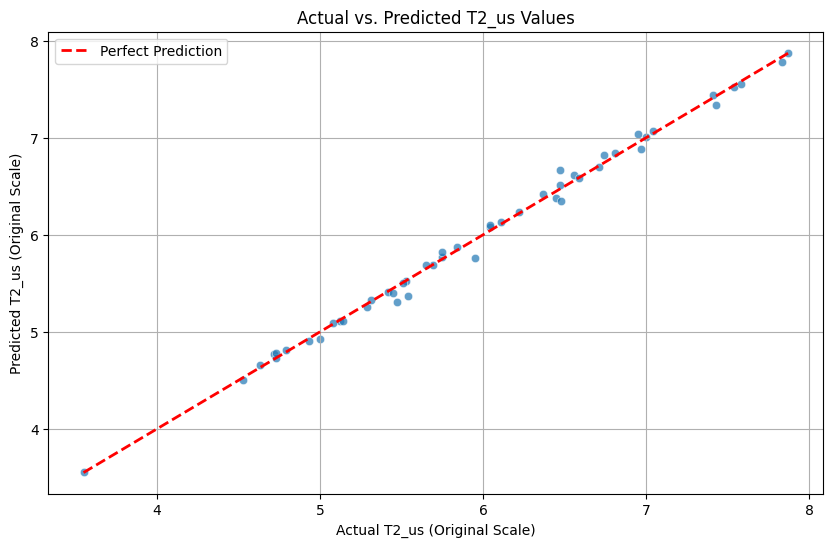

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize predictions vs. actuals
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_original.flatten(), y=y_pred_original.flatten(), alpha=0.7)
plt.plot([min(y_test_original), max(y_test_original)], [min(y_test_original), max(y_test_original)], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual T2_us (Original Scale)')
plt.ylabel('Predicted T2_us (Original Scale)')
plt.title('Actual vs. Predicted T2_us Values')
plt.grid(True)
plt.legend()
plt.show()